# Week 7: Human Activity Recognition w/ Neural Networks

**What is the ask?** Train a neural network to classify human activity based on 3-axis accelerometer data

**Why is this important?** Demand for AI running directly on "edge" hardware, not in the cloud, is real and growing.  Some of the primary factors driving this are high data communiations costs (in terms of both money and electrical power), low tolerance for network induced delays or reliability problems, and privacy concerns.  Today (2026), only about 15% of ML engineers know microcontroller programming, and fewer than 5% of embedded engineers understand neural network optimization techniques. Add yourself to the select few with these skills and, if this type of work interests you, the jobs are out there in IoT expansion, smart sensors, battery-powered AI devices, privacy-focused applications, and custom AI hardware development (to name a few market segments)!

**Group Project Guidance** Continue working with your partner(s) from last week's lab.  
* You will use two different hardware designs this week.  
* Use one of your group's boards for this programming assignment (you will modify last week's project to generate datasets with 25 samples per second).  
* Use another one of your group's boards for this week's associated lab assignment.  
* All members of your group should use the same datasets generated in this programming assignment.
* *You should perform the checkpoints in this lab independently - your code implementations, results, and answers should be your own*  

This notebook is based on the following resources: 
* [Human Activity Recognition Google CoLab (STM)](https://colab.research.google.com/github/STMicroelectronics/stm32ai/blob/master/AI_resources/HAR/Human_Activity_Recognition.ipynb)
* [How to perform motion sensing on STM32L4 IoT Node](https://wiki.st.com/stm32mcu/wiki/AI:How_to_perform_motion_sensing_on_STM32L4_IoTnode)


## Checkpoint 0 - Group Members

Add the names of all members in your group below:

*Victor Lun Pun, Olir Eswaramoorthy*

## Overview

You will first go through each section below to understand how the Python code draws data from saved datasets, trains a neural network, validates the model, and then saves the model in a portable "tensorflow lite" (tflite) data format.  You will exercise each of these steps using an existing dataset with "stationary", "walking", and "running" accelerometer recordings.

You will then enhance this project with a fourth activity of your own choosing.  Using the 3-axis accelerometer project you built in weeks 5 and 6 of the course you will create new training data sets, retrain the model, and again validate its performance in classifying the four motion profiles.

Once satisfied with the performance in python/tensorflow, you will export the model in a tensorflow-lite format and demonstrate it running on hardware in the associated W26-W7-LA laboratory exercise.

Ready to begin?

First lets validate your environment.  The following should return a valid version >= 2.20.0:

In [1]:
#Verify Tensorflow installation and version:
import tensorflow as tf
print(tf.version.VERSION)

c:\Users\brand\Documents\ENGS-62-Workspace\W26-W7-PA\.venv\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


2.20.0


## Baseline Training

Datasets are stored in the project 'dataset' folder in sub-folders for each motion class (defined as 'labels' in the code below).  Open one up and note the structure: comma separated values, three columns, in integer (milli-gravities) units.  

Each file has 1000 rows.  When you add a new motion classification (in your second pass through this programming assignment) make sure your new datasets have 1000 rows (not 999, or 1001) to match this format and make sure you store them in a sub-folder with the same name as your new label in the 'labels' array in the code below.

This code builds two data structures: x_recordings[] and y_recordings[].  

x_recordings is a three-dimensional array (aka a 'rank 3' tensor).  The first dimension is a dataset index (in the first past through you'll notice there are 93 datasets in x_recordings: 18 running + 36 stationary + 39 walking = 93 ).  The second dimension is the dataset's temporal (time) dimension, and the third dimension indexes the accelerometer's x, y, and z data channels.

y_recordings[] contains the 93 labels ('running', 'stationary', 'walking') associated each of the 93 datasets. 

When you add new datasets later on, the number 93 should grow by however many new datasets you add, but the x_recordings[] second (1000) and third (3) dimensions should not chanage.

In [4]:
#Load datasets
import glob
import numpy as np

import glob
import numpy as np

# Load data into memory
labels = ['stationary', 'walking', 'running', 'spinning'] #Add the new motion "spinning"
x_recordings = []
y_recordings = []
recordings_filenames = []
for i, label in enumerate(labels):
    filenames = glob.glob('dataset/' + label + '/*.csv')
    for filename in filenames:
        data = np.loadtxt(filename, delimiter=',')
        x_recordings.append(data)
        y_recordings.append(i)
        recordings_filenames.append(filename)

x_recordings = np.array(x_recordings).reshape(len(x_recordings), -1, 3)
y_recordings = np.array(y_recordings)

print(x_recordings.shape)
print(y_recordings.shape)

(112, 1000, 3)
(112,)


The following code randomly selects 10 datasets from x_recordings[] and plots them.  Notice that the provided datasets are from an accelerometer with +/- 4g range sampling at 26 Hz.  Your accelerometer is +/- 2g and will be configured to sample at 25 Hz... although your sampling rate is not identical to the provided dataset sampling rates, it is "close enough."

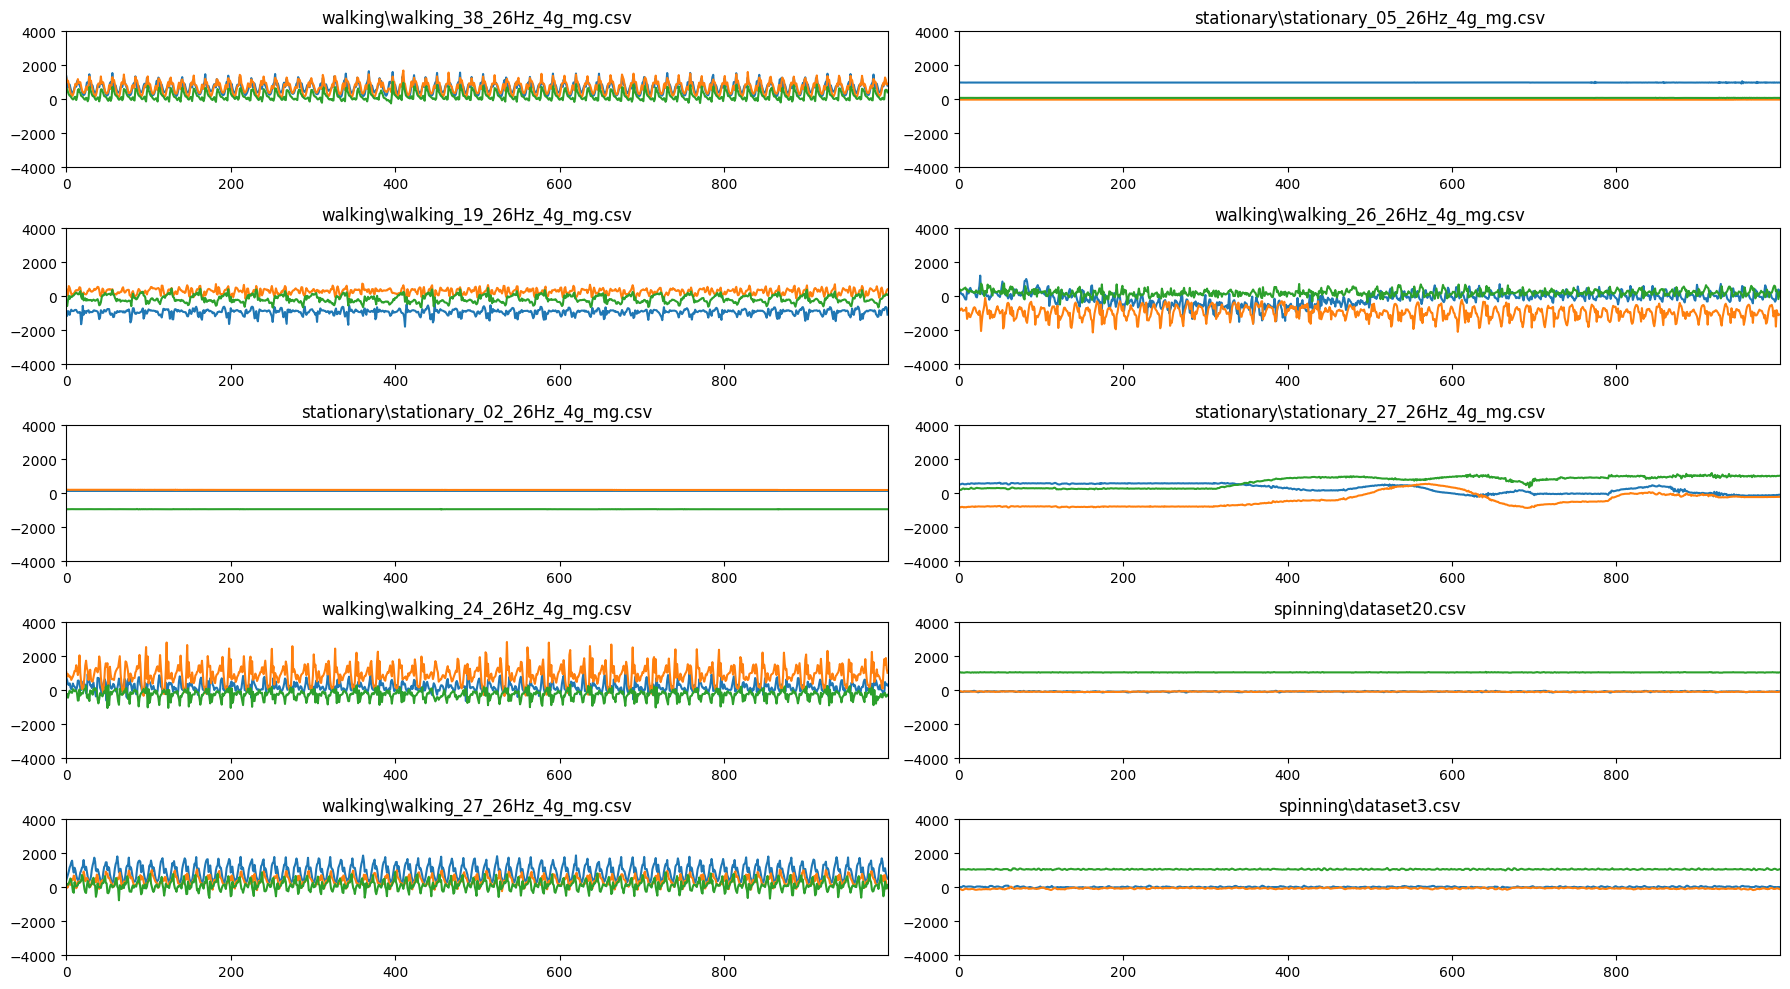

In [5]:
# Visualize some of the (92) datasets loaded, each with 1000 sample points

import random
import matplotlib.pyplot as plt
%matplotlib inline

# Plot some captures
random.seed(10)
unique_rands = random.sample(range(len(x_recordings)), 10)
plt.figure(figsize=(18, 10))
for i, n in enumerate(unique_rands):
    plt.subplot(5, 2, i + 1)
    plt.margins(x=0, y=-0.25)
    plt.plot(x_recordings[n])
    plt.ylim(-4000, 4000)  # 4000 mg acc. range
    plt.title(recordings_filenames[n].split('/')[-1])
plt.tight_layout()
plt.show()

The following function lets you generate "windows" of the training data... you do not provide all 1000 samples of an acceleration channel's output to the model at once.  Instead you will use a "window" into the 1000 samples, say 26 samples wide.

You might chunk the 1000 samples up into separate windows, e.g. window #1 contains samples 1-26, window #2 contains samples 27-52, etc...  or you might overlap them, e.g. window #1 contains samples 1-26, window #2 contains samples 13-38, etc... you can experiment with different overlap to see how it affects your training results.

In [6]:
# Utility function to frame the data into "input windows" for evaluation by the CNN
import numpy as np

def frame(x, frame_len, hop_len):
    '''Slice a 3D data array into (overlapping) frames.
    
    Example
    --------
    >>> x = np.array([[0, 1, 2],
                      [10, 11, 12],
                      [20, 21, 22],
                      [30, 31, 32],
                      [40, 41, 42],
                      [50, 51, 52],
                      [60, 61, 62]])
    >>> frames = x.frame(x, 3, 2)
    >>> x.shape
    (7, 3)
    >>> frames.shape
    (3, 3, 3)
    '''

    assert(x.shape == (len(x), 3))
    assert(x.shape[0] >= frame_len)
    assert(hop_len >= 1)

    n_frames = 1 + (x.shape[0] - frame_len) // hop_len
    shape = (n_frames, frame_len, x.shape[1])
    strides = ((hop_len * x.strides[0],) + x.strides)
    return np.lib.stride_tricks.as_strided(x, shape=shape, strides=strides)


The next code cell uses the above "frame()" function to generate frames from the input datasets, turning eg 93 datasets of 1000 samples per acceleration channel into 6900 frames of 26 samples per acceleration channel (with some overlap). 

In [7]:
# Generate framed data (with or without overlap)

x_frames = []
y_frames = []
for i in range(x_recordings.shape[0]):
    # frames = frame(x_recordings[i], 26, 26) # no overlap
    frames = frame(x_recordings[i], 26, 13) # 50% overlap
    x_frames.append(frames)
    y_frames.append(np.full(frames.shape[0], y_recordings[i]))

x_frames = np.concatenate(x_frames)
y_frames = np.concatenate(y_frames)
print(x_frames.shape)
print(y_frames.shape)

(8400, 26, 3)
(8400,)


Whatever pre-processing you do here should be replicated, identically, in your actual implementation.  Because the provided datasets have a full-scale range of +/- 4 gravities (4000 milli-gravities), the values are divided by 4000 such that the neural network input range is +/- 1.000.  A sampled value of 1000 (milli-gravities) will convert to the value 0.25.  

You can experiment with different pre-processing technniques at your leisure (e.g. removing DC bias with a high pass filter) but, again, be sure your C code implementation performs identical pre-processing!

In [8]:
# Perform any pre-processing on the dataset here:

# Normalize input data between [-1;1]
x_frames_normed = x_frames / 4000

Pull out 75% of the windows you just generated to use for training.  Reserve the other 25% of the windows for validation (you do not want to validate with the same data you used for training!). The train_test_split() function, imported from the sklearn package, "shuffles" the windows to randomly select 75% of the windows.  You should get different training and test window sets each time you run this code cell.

In [9]:
# Shuffle the dataset and then split with 75% for training and 25% for testing

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x_frames_normed, y_frames, test_size=0.25)

print("Trainning samples:", x_train.shape)
print("Testing samples:", x_test.shape)

Trainning samples: (6300, 26, 3)
Testing samples: (2100, 26, 3)


Next, create a network with three hidden layers (and train it).  

The first layer has three "channels" (x,y,z acceleration) and expects 26 "temporal" (time series) acceleration samples per channel.  1D convolution is performed on the input data, with 16 convolution "match filters."  The kernel_size=3 implies that 3 matching filter coefficient are "slid" across each of the three temporal data channel samples, but the actual kernel is size 3x3 (kernel_size x # of channels) and it slides across all three channels simultaneously.  

So if the input data is:

x: 1 1 1 0 0 0 0 0 0 0 0 0 ...

y: 2 2 2 1 1 1 0 0 0 0 0 0 ...

z: 3 3 3 2 2 2 1 1 1 0 0 0 ... 

And one of the 3x3 kernel's coefficients are:

1 0 0

0 1 0

0 0 1

The results of this filter will be:

1+2+3 1+2+2 1+1+2 0+1+2 0+1+1 0+0+1 0+0+1 0+0+0 .... 

For an input with 26 temporal samples, there will be 24 results per filter.  

Since there are 16 filters, the input layer will generate an output with shape 24,16 from an input with shape 26,3.  

Review this until you see how it ties together!

The second layer performs convolution again, this time on the results of the first convolution layer.  Its inputs have shape 24,16, but there are only 8 filters, so its output shape is 22,8.

Dropout isn't a real layer.  During training, at each time step, a percentage of the neurons in the previous layer have their values set to 0.  In the code below 50% of the neurons in the previous layer are set to 0.  This is a technique to prevent "overfitting"... the network is made less reliant on any particular neuron during training when it is randomly set to 0.  When the network runs on your microcontroller this does not occur.

Flatten is not a real layer either.  Flatten does exactly what it sounds like... the output of the previous layer has shape 22,8 (2 dimensional) and 'flatten' transforms this into a 1D shape 22*8 = 176.  These 176 neuron values are then densely connected to the last hidden layer of 64 neurons.  That means each of the 176 neurons in the (flattened) previous layer are connected to each of the 64 neurons in the last hidden layer... so 176 * 64 = 11,264 connections between the two layers!  (thinking back to the first few weeks of class... that's a lot of multiplication and addition!)

The output layer is, again, densely connected to the previous layer's 64 neurons.  The output layer has one neuron per motion class - so three to start (but four when you add a new motion class!) and it uses a new activation function, softmax.  Softmax normalizes the neuron values in the output layer so that the sum of the values = 1.00.  This can be interpreted as a probability distribution with each of the output neurons representing the 'probability that the observed motion is this neuron's motion class'.  For example, if:

* The 1st output neuron is the probability of 'stationary' = 0.02
* The 2nd output neuron is the probability of 'walking' = 0.93
* The 3rd output neuron is the probability of 'running' = 0.05

Then the observed motion is probably 'walking'!

So that's how this particular network is structured... and feel free to experiment with network structure (after you get the provided network structure working) to see how it affects accuracy, performance (execution time), and cost (memory requirements)!

Ready to train it?  

Remember, you want high 'accuracy' results at the end of training (e.g. > 0.95) and low 'loss' results (e.g. < 0.10).  You can re-train until you are satisfied with the results.  

In [10]:
# Create and train the model

## Conv1D based model
model = tf.keras.models.Sequential([
  tf.keras.layers.Conv1D(filters=16, kernel_size=3, activation='relu', input_shape=(26, 3)),
  tf.keras.layers.Conv1D(filters=8, kernel_size=3, activation='relu'),
  tf.keras.layers.Dropout(0.5),
  tf.keras.layers.Flatten(),
  tf.keras.layers.Dense(64, activation='relu'),
  tf.keras.layers.Dense(4, activation='softmax')
])
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.fit(x_train, y_train, epochs=30)
test_loss, test_acc = model.evaluate(x_test,  y_test, verbose=2)

print("Test loss:", test_loss)
print("Test acc:", test_acc)
model.summary()

c:\Users\brand\Documents\ENGS-62-Workspace\W26-W7-PA\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6141 - loss: 0.9267
Epoch 2/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8098 - loss: 0.4780
Epoch 3/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9022 - loss: 0.2976
Epoch 4/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9256 - loss: 0.2255
Epoch 5/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9390 - loss: 0.1917
Epoch 6/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9413 - loss: 0.1751
Epoch 7/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9424 - loss: 0.1720
Epoch 8/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9452 - loss: 0.1670
Epoch 9/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9486 - loss: 0.1545
Epoch 10/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9497 - loss: 0.1505
Epoch 11/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9516 - loss: 0.1446
Epoch 12/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 24, 16)         │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 22, 8)          │           392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 22, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 176)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        11,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,422 (142.28 KB)

 Trainable params: 12,140 (47.42 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 24,282 (94.86 KB)

Now run predictions using the reserved test data to see how well the training worked.  Generate a heat map showing right/wrong guesses vs. truth by motion class:

66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


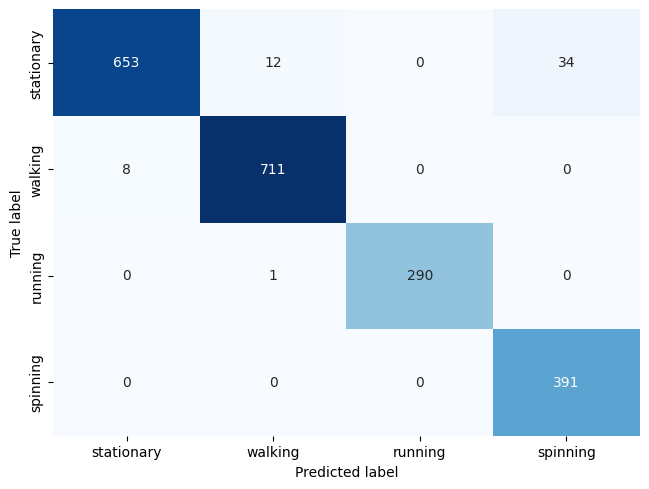

In [13]:
# Evaluate the training parameters on test data

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

Y_pred = model.predict(x_test)
y_pred = np.argmax(Y_pred, axis=1)
confusion_matrix = tf.math.confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(confusion_matrix,
            annot=True,
            xticklabels=labels,
            yticklabels=labels,
            cmap=plt.cm.Blues,
            fmt='d', cbar=False)
plt.tight_layout()
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

And once you are happy with the results, save it to both a 'standard' file format (.h5) and to a 'lightweight' format for use with the microcontroller (.tflite)

In [14]:
# Happy?  Save the model and move it to the microcontroller

model.save('model.keras')

# Convert to tflite

converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open('model.tflite', 'wb') as f:
          f.write(tflite_model)

INFO:tensorflow:Assets written to: C:\Users\brand\AppData\Local\Temp\tmperc0vpbg\assets


INFO:tensorflow:Assets written to: C:\Users\brand\AppData\Local\Temp\tmperc0vpbg\assets


Saved artifact at 'C:\Users\brand\AppData\Local\Temp\tmperc0vpbg'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 26, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  2868961368912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2868961364688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2868961372176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2868961368336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2868961367376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2868961366416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2868961369296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2868961365840: TensorSpec(shape=(), dtype=tf.resource, name=None)


## Checkpoint 1 - Baseline Training

Everything working?  Great!

Replace my image, below, with an image showing the final accuracy and loss values from the last training epoch (#162) of your training session:

<!-- ![Training Results](images/CP1_Training_Results.png) -->
![Brandon Training Results](images/checkpoint1(BDC_Results).png)

*Grading Rubric: [10 points]*
* -10 points: missing image
* -1 to -5 points: poor accuracy results (< 0.95) 
* -1 to -5 points: poor loss results (> 0.1)

Replace my image, below, with an image showing your validation results:

<!-- ![Validation Results](images/CP1_Validation_Results.png) -->
![Brandon Heat Map Results](images/checkpoint1(BDC_HeatMap).png)

*Grading Rubric: [10 points]*
* -10 points: missing image
* -1 to -10 points: poor validation results off-diagonal (incorrect classifications > 50)



## Enhanced Training

Time to add a new motion classification!  

Use your SPI-enabled accelerometer and USB-based serial terminal communications (CoolTerm or Tera Term) to collect > 20 datasets for a new motion profile.

* **Change the accelerometer's sampling rate to 25 Hz!** 
* Look at the format of the existing dataset/\<classification\>/\<datafile\>.csv files.  Modify your printf() statement as necessary to match the dataset file format!
* Make sure each dataset only has 1000 rows of data in it
* Make sure each dataset has full data in each row (x,y,z data)
* Modify the 'labels' array in the code above with your new motion classification
* Train until you are happy!

*Keep in mind that the accelerometer only has a full scale range of +/- 2 Earth's gravities ("g's").  Choose new motion classes that are in this range, or modify the accelerometer's full scale range to +/- 4 Earth's gravities ("g's") and adjust your code to scale the results accordingly!*

## Checkpoint 2 - Enhanced Training

Describe your new motion class:

*Spinning, in honor of the Winter Olympics.*

*Grading Rubric [2 points]:*
* -1: improbable motion class based on accelerometer capabilities
* -1: poorly described motion class

Provide your accuracy and loss values from your last training epoch as an image, below.  Note there is no accuracy or loss criteria for grading... these values will depend on your chosen motion profiles and associated dataset quality.  I just want to see what your results are:

![Brandon New Motion Results](images/checkpoint2(BDC_Results).png)

*Grading Rubric [5 points]:*
* -5: no image / incorrect image provided

Provide your validation results as an image, below.  Note again there are no validation criteria for grading... these values will depend on your chosen motion profiles and associated dataset quality.  I just want to see what your results are:

![Brandon New Heat Map](images/checkpoint2(BDC_HeatMap).png)

*Grading Rubric [5 points]:*
* -5: no image / incorrect image provided

Describe the following aspects of your experiences in generating the above results.  Grading rubric for all questions/answers is the same:

*Grading Rubric [5 points each]:*
* -5: no answer
* -1 to -2: depth and quality of 'challenge' description
* -1 to -3: depth and quality of 'how you worked through the challenge' explanation.

Data Collection: describe a challenge you encountered when collecting acceleration datasets.  This can be a hardware/software challenge, or related to the experimental aspects of collecting data with your hardware/software, or related to "cleaning up" the data for use in training.  Explain how you worked through this challenge.  

*At first we tried to copy and paste and just the buffer results of the data we were collecting, but soon found out that it only displayed 400-500 samples before it started cutting off. In order to get around this problem we looked into how to have CoolTerm outputs as a `.txt` file in order to capture all the data we needed per run. Additionally, in terms of experimental aspects of collecting data, it ended up being quite difficult to collect 20 datasets of 1000 samples for spinning. All three of us tried to rotate, but got increasinly more nautious throughout the experiment. Worth the collection though.*

Training: describe a challenge you encountered when training the network with your new datasets.  This can be a software challenge, related to the training process/workflow, or relating to a need to adjust your chosen motion class based on training findings ('accuracy' and 'loss' metrics).  Explain how you worked through this challenge.

*The way our results were saved through CoolTerm were saved as whole lines. In order for them to be in the same format as all of our other datasets it took some time to go through, separate each of the datasets to have at least 1000 samples, and make sure the formatting was uniform with the other files so that we wouldn't need to change much of already existing code to retrain the model. In addition to this, we realized that our implementation of reading the accelerometer data was wrong. We swapped the y-axis and z-axis labels so we needed to clean the data by swapping the values between the two columns.*

Validation: describe a challenge you encountered when validating the network.  This can be a software challenge, related to the training process/workflow, or relating to a need to adjust your chosen motion class based on validation findings ('predicted labels' vs 'true labels').  Explain how you worked through this challenge.

*Suprisingly, when we ran our trianing the first time and generated our heat map again it seemed to classify each movement surprisingly well. In order to make sure this wasn't a one-off occurance we ran the training again to make sure that everything was consistent. The challenge was to make sure we weren't getting lucky with our results and validation, and we worked through this by running the results a couple more times to make sure it was consistent.*

The following two questions are the ones I care about most as an educator (all grading aside).  You receive full credit for any answer.  You only lose (full) credit for not answering.

Assuming the validation results you achieved above represent real-world performance of the physical system (running in hardware, which you will implement in the associated lab assignment):

What are the strengths of this "data driven" approach to implementing human motion classification vs. "hand coding" feature extraction and motion classification algorithms, as you did last week?

*Some of the strengths that come with this "data driven" approach to classification is that we can use real-world data in order to tune the parameters to what we were seeing in real life. Another strength is that we can observe new movement classes and use that data to create another set of neural network parameters and implement that into our model without much friction.*

*Grading Rubric [5 points]*
* -5: no answer

What are the weaknesses of this "data driven" approach to implementing human motion classification vs. "hand coding" feature extraction and motion classification algorithms, as you did last week?

*Some of the weakness of this "data driven" approach is that we needed to obtain a significant amount of data in order to learn the parameters for each class of motion. When we "hand coded" the feature classification from last week, the approach that we went with was to use threshold values to change the classification. This required a lot less data to be collected.*

*Grading Rubric [5 points]*
* -5: no answer

## Conclusion

I hope you found this programming assignment illuminating (and enjoyable).  AI/ML "data driven" techniques are both extremely powerful and relatively new (in the world of embedded systems).  They enable a new paradigm for programming a device's behavior, but they are not necessarily a full replacement of the established rules-based (e.g. C coded algorithms) development practices.  

In this programming assignment you experienced the workflow for dataset generation and model training for a practical, real-world system - a human motion classifier.  In the associated lab, you will implement the model in hardware.  Exciting!

Congratulations on finishing this week's programming assignment.  Save your work, commit it, and sync (push) it to your remote GitHub repo.  Then celebrate - job well done!